# Task 11: Vision Transformer (ViT) from Scratch



In [1]:
!pip -q install einops transformers

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from einops import rearrange
from PIL import Image

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Create a Simple Image

A random high-resolution image is used so the notebook runs without downloading a dataset.

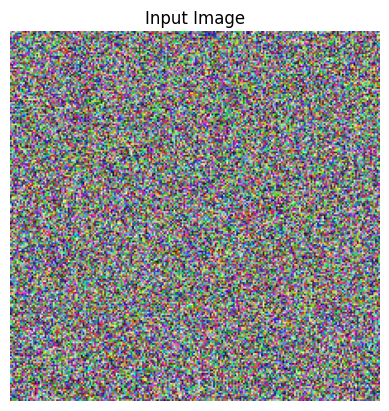

In [2]:
# Random RGB image: 224 x 224
image = torch.rand(1, 3, 224, 224)

plt.imshow(
    image[0].permute(1, 2, 0)
)
plt.title("Input Image")
plt.axis("off")
plt.show()

## 2. Patch Projection


In [3]:
class PatchProjection(nn.Module):

    def __init__(self, image_size=224, patch_size=16,
                 channels=3, embed_dim=64):

        super().__init__()

        self.patch_size = patch_size

        # Number of pixels in one patch
        patch_dim = channels * patch_size * patch_size

        # Custom linear projection
        self.projection = nn.Linear(
            patch_dim,
            embed_dim
        )

    def forward(self, x):

        # Convert image into patches
        patches = rearrange(
            x,
            "b c (h p1) (w p2) -> b (h w) (c p1 p2)",
            p1=self.patch_size,
            p2=self.patch_size
        )

        return self.projection(patches)


patch_layer = PatchProjection()

patches = patch_layer(image)

print("Patch embedding shape:", patches.shape)

Patch embedding shape: torch.Size([1, 196, 64])


## 3. Multi-Head Self-Attention



In [4]:
class MultiHeadAttention(nn.Module):

    def __init__(self, embed_dim=64, heads=4):

        super().__init__()

        self.heads = heads
        self.head_dim = embed_dim // heads

        self.qkv = nn.Linear(
            embed_dim,
            embed_dim * 3
        )

        self.output = nn.Linear(
            embed_dim,
            embed_dim
        )

    def forward(self, x):

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        # Split embedding into attention heads
        q = rearrange(
            q,
            "b n (h d) -> b h n d",
            h=self.heads
        )

        k = rearrange(
            k,
            "b n (h d) -> b h n d",
            h=self.heads
        )

        v = rearrange(
            v,
            "b n (h d) -> b h n d",
            h=self.heads
        )

        # Attention scores
        scores = torch.matmul(
            q,
            k.transpose(-2, -1)
        ) / (self.head_dim ** 0.5)

        attention = torch.softmax(
            scores,
            dim=-1
        )

        # Weighted values
        out = torch.matmul(
            attention,
            v
        )

        out = rearrange(
            out,
            "b h n d -> b n (h d)"
        )

        return self.output(out), attention

## 4. Simple Vision Transformer Block



In [5]:
class SimpleViT(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch = PatchProjection()

        # 224 / 16 = 14, so there are 14 x 14 = 196 patches.
        num_patches = 196
        embed_dim = 64

        # Learnable class token
        self.cls = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )

        # Learnable positional embedding
        self.pos = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim)
        )

        self.attention = MultiHeadAttention(
            embed_dim=64,
            heads=4
        )

        self.norm = nn.LayerNorm(64)

        self.ffn = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )

    def forward(self, x):

        x = self.patch(x)

        batch = x.size(0)

        # Add class token
        cls = self.cls.expand(
            batch, -1, -1
        )

        x = torch.cat(
            [cls, x],
            dim=1
        )

        # Add position information
        x = x + self.pos

        # Self-attention
        attn_out, attention = self.attention(
            self.norm(x)
        )

        x = x + attn_out

        # Feed-forward network
        x = x + self.ffn(
            self.norm(x)
        )

        return x, attention


model = SimpleViT().to(device)

output, attention = model(
    image.to(device)
)

print("ViT output shape:", output.shape)
print("Attention shape:", attention.shape)

ViT output shape: torch.Size([1, 197, 64])
Attention shape: torch.Size([1, 4, 197, 197])


## 5. Visualize an Attention Map

The first token is the class token, so we visualize how it attends to the image patches.

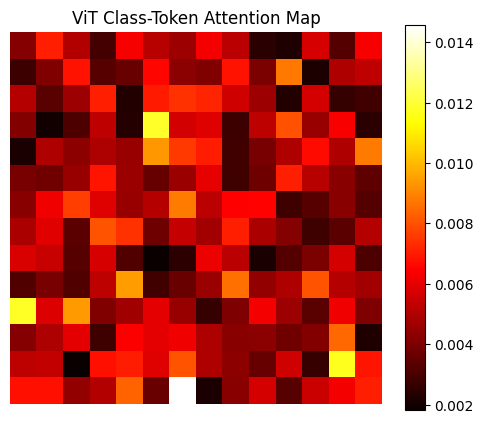

In [6]:
# Select the first attention head
attn = attention[0, 0]

# Class token attention to all image patches
cls_attention = attn[0, 1:]

# Convert 196 patches into a 14 x 14 grid
attention_map = cls_attention.reshape(14, 14)

plt.figure(figsize=(6, 5))

plt.imshow(
    attention_map.detach().cpu(),
    cmap="hot"
)

plt.colorbar()
plt.title("ViT Class-Token Attention Map")
plt.axis("off")
plt.show()